In [1]:
import torch
import ChemSurrogate.data_processing as dp
from ChemSurrogate.configs import (
    AEConfig,
    )
from ChemSurrogate.trainer import (
    load_skipcon_emulator_objects,
    )
import matplotlib.pyplot as plt
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


species_of_interest = ["H", "H2", "O", "C", "N", "SPlus", "MG", "SIPlus", "CL", "CPlus", "BULK_CO", "BULK_H", "E_minus", "CO", "BULK_CO"]
#species_of_interest = ["H", "H2", "O", "C", "N", "CL", "E_minus", "CO"]

In [2]:
# Load the models.
emulator, autoencoder, _, _ = load_skipcon_emulator_objects(is_inference=True)

# Load the datasets
training_t, training_indices = dp.load_tensors_from_hdf5(category="training")
validation_t, validation_indices = dp.load_tensors_from_hdf5(category="validation")

Inference Mode Activated (parameters frozen)
Total Parameters: 280088


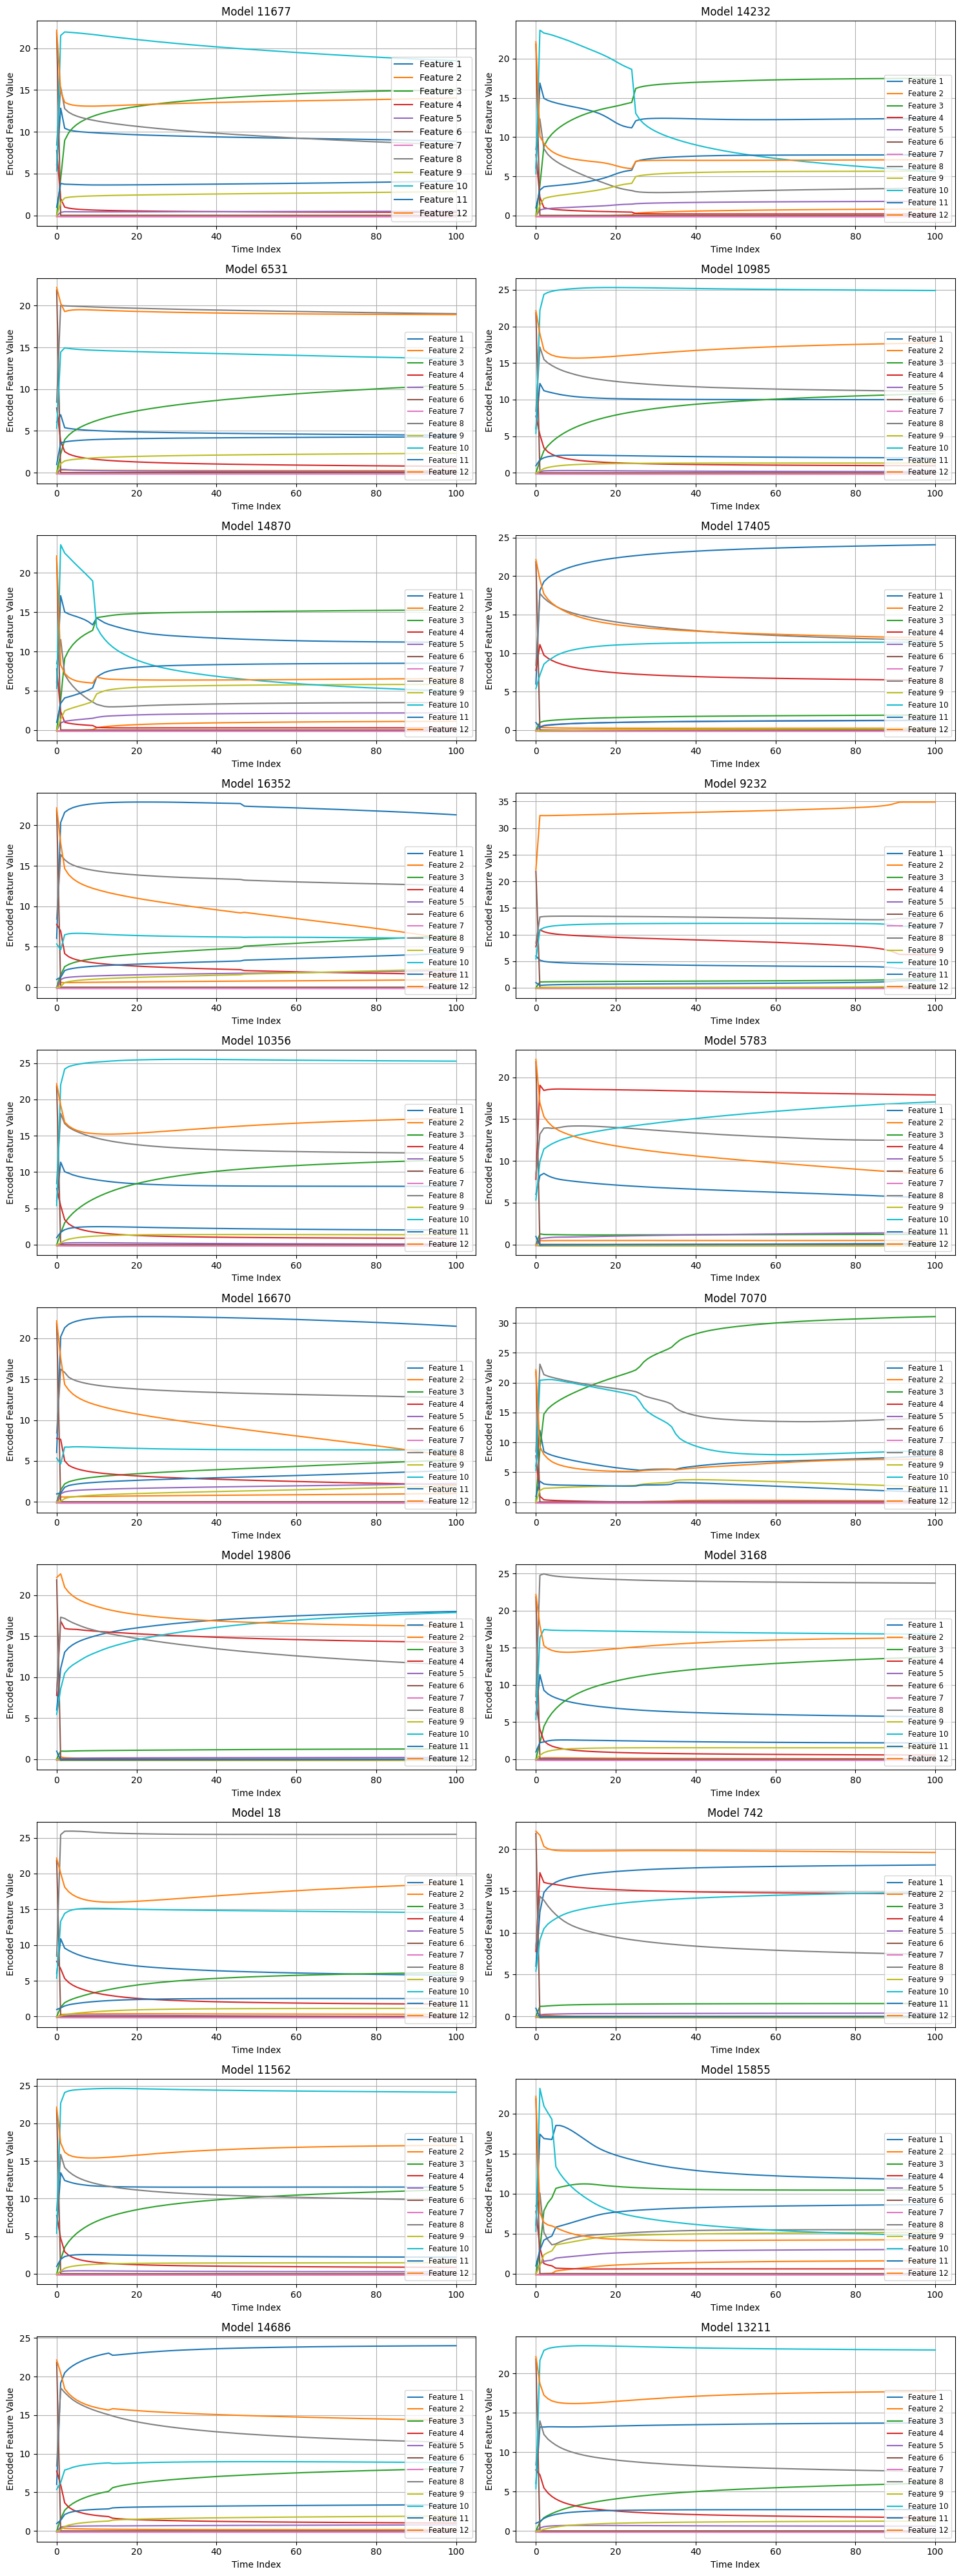

In [3]:
num_plots = 10 * 2
sampled_model_indices = random.sample(range(20000), num_plots)

fig, axes = plt.subplots(int(num_plots//2), 2, figsize=(15, num_plots*2))
axes = axes.flatten()

for plot_idx, model_idx_num in enumerate(sampled_model_indices):
    model_idx = validation_t[:, 1].unique()[model_idx_num]
    
    model_np = validation_t[validation_t[:, 1] == model_idx][:, 2:-AEConfig.latent_dim].numpy()
    
    abundances = model_np[:, 1:]
    abundances_t = torch.from_numpy(abundances)
    
    with torch.no_grad():
        encoded_features = dp.encoder_inferencing(autoencoder, abundances_t)
    
    time_indices = (model_np[:, 0] / 1000)
    encoded_features_np = encoded_features.cpu().numpy()
    
    for i in range(encoded_features_np.shape[1]):
        axes[plot_idx].plot(time_indices, encoded_features_np[:, i], label=f'Feature {i+1}')
    
    axes[plot_idx].set_xlabel("Time Index")
    axes[plot_idx].set_ylabel("Encoded Feature Value")
    axes[plot_idx].set_title(f"Model {model_idx_num}")
    axes[plot_idx].grid(True)
    
    if plot_idx == 0:
        axes[plot_idx].legend(loc="lower right")
    else:
        axes[plot_idx].legend(loc="lower right", fontsize='small')

plt.tight_layout()
plt.show()